## Validation of FHS volatility and residual independence assumptions

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from statsmodels.graphics.tsaplots import plot_acf

from src.data.loaders import load_prices
from src.portfolio.positions import Portfolio
from src.risk.volatility import _ewma_volatility
from src.risk.diagnostics import residual_diagnostics

In [2]:
tickers = [
    "AAPL","MSFT","AMZN","GOOGL","META",
    "NVDA","JPM","UNH","XOM","PG"
]

prices = load_prices(
    tickers=tickers,
    start="2012-01-01",
    end="2025-12-31"
)

returns = prices.pct_change().dropna()

weights = np.ones(len(tickers)) / len(tickers)

portfolio = Portfolio(tickers=tickers, weights=weights, notional=10_000_000)

Cached prices available
Cached data covers request. Loading from cache.


### Compute Standardized Residuals & Run Diagnostics

In [3]:
lambda_ = 0.94

vol = _ewma_volatility(returns, lambda_)

standardized = returns / vol

standardized = standardized.iloc[50:]   # burn-in

diagnostics = residual_diagnostics(standardized)

diagnostics

,asset,mean,variance,ljung_box_pvalue,ljung_box_sq_pvalue
0,AAPL,0.065234,1.148047,0.042603,0.958004
1,MSFT,0.078223,1.168732,0.050630,0.938611
2,AMZN,0.066012,1.218408,0.855282,0.994895
3,GOOGL,0.071424,1.229862,0.283751,0.998945
4,META,0.063212,1.372276,0.454556,0.999277
5,NVDA,0.093191,1.243388,0.553392,0.983709
6,JPM,0.061288,1.134317,0.348368,0.256924
7,UNH,0.057766,1.172587,0.083707,0.966745
8,XOM,0.017233,1.097353,0.962371,0.025284
9,PG,0.036185,1.148644,0.027423,0.709709


Mean standardized residuals are close to 0, variances are close to 1.

Ljung-Box p-values on squared residuals are mostly > 0.05, failing to reject the zero autocorrelation hypothesis. This suggests that the EWMA volatility filter successfully removes most volatility clustering from the returns.

Ljung–Box tests applied to standardized residuals reject the null hypothesis of zero autocorrelation for several assets. This indicates the presence of mild serial dependence in the filtered residuals. Such behavior is common in financial return series and reflects dynamics not captured by the volatility model.

EWMA targets conditional heteroskedasticity rather than serial correlation in the mean. The key diagnostic is whether autocorrelation in squared residuals remains. Since the squared residuals show little autocorrelation, the volatility filter appears to perform adequately.

### Residuals Histogram

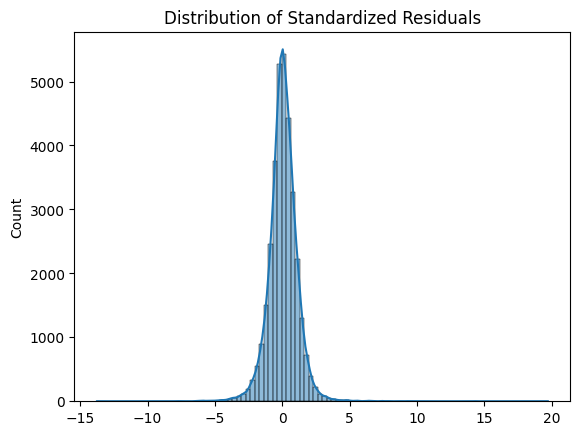

In [4]:
z = standardized.stack().to_numpy()

plt.figure()
sns.histplot(z, bins=100, kde=True)
plt.title("Distribution of Standardized Residuals")
plt.show()

Residuals are visually centered around 0.

### ACF Plots for Autocorrelation

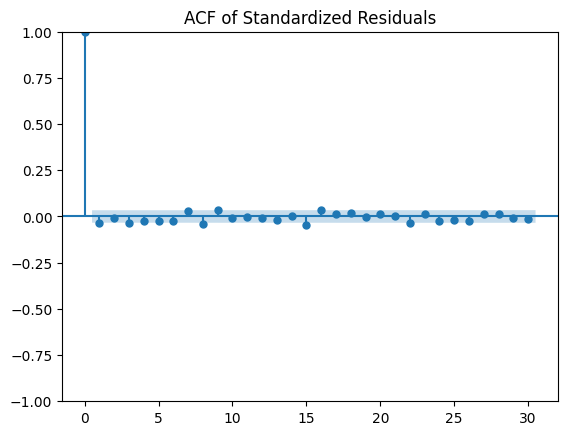

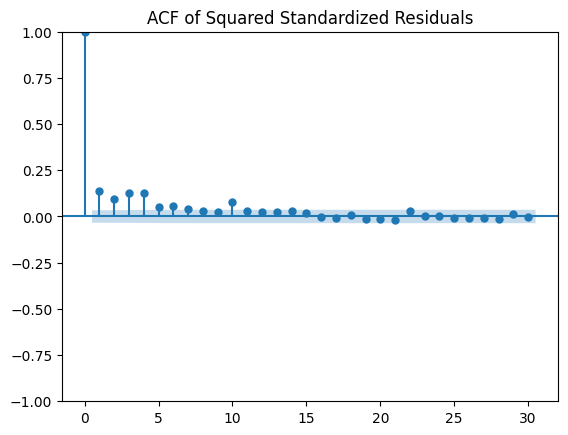

In [5]:
portfolio_resid = standardized @ portfolio.weights

plot_acf(portfolio_resid, lags=30)

plt.title("ACF of Standardized Residuals")
plt.show()

plot_acf(portfolio_resid**2, lags=30)

plt.title("ACF of Squared Standardized Residuals")
plt.show()

No siginificant autocorrelation observed in standardize residuals as almost all correlations across all lags rest within the confidence interval.

Weak autocorrelations observed in squared standardized residuals as most correlations across all lags rest within the confidence interval, with some correlations at small lags.

### EWMA volatility vs returns

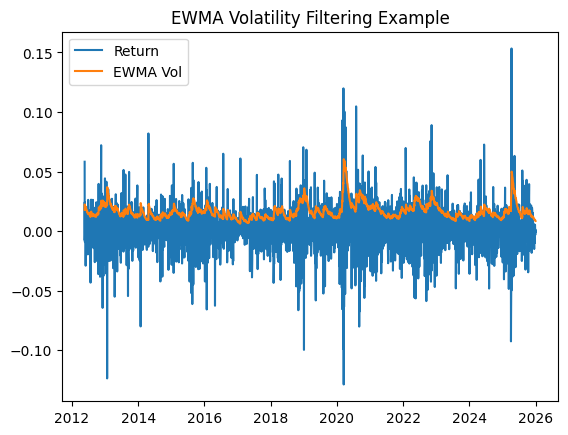

In [6]:
plt.figure()

plt.plot(returns.index, returns["AAPL"], label="Return")
plt.plot(vol.index, vol["AAPL"], label="EWMA Vol")

plt.legend()
plt.title("EWMA Volatility Filtering Example")

plt.show()

EWMA volatility spikes during periods of large returs and declines during periods of smaller returns. This indicates that the model captures time-varying volatility.

### Standardized Residuals vs Time

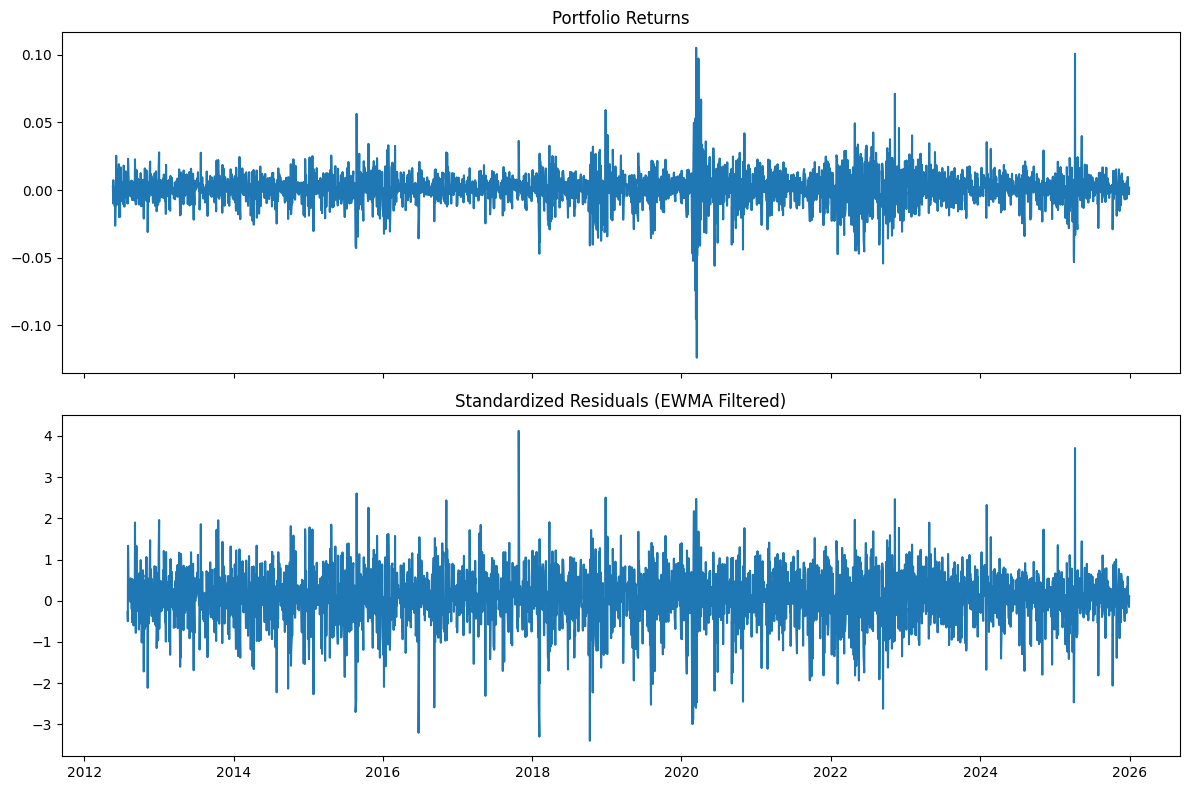

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

portfolio_returns = returns @ portfolio.weights
portfolio_resid = standardized @ portfolio.weights

ax[0].plot(portfolio_returns)
ax[0].set_title("Portfolio Returns")

ax[1].plot(portfolio_resid)
ax[1].set_title("Standardized Residuals (EWMA Filtered)")

plt.tight_layout()
plt.show()

The EWMA volatility filter removes most volatility clustering present in the raw returns.
The standardized residuals exhibit approximately constant variance over time, supporting the assumption that the filtered shocks are approximately iid.